# <center>Procesamiento Digital de Señales de Audio</center>
### <center>Instituto de Ingeniería Eléctrica - UdelaR</center>
## <center> Síntesis de formantes</center>

### Como correr este notebook

Es posible descargarlo y correrlo localmente en su computadora

Tambien pueden correrlo en Google Colab usando el siguiente link.

<table align="center">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/emidan19/audio-dsp/blob/main/practicos/P1b-formantes.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Correr en Google Colab</a>
  </td>
</table>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import io, signal
from scipy.io.wavfile import read
from IPython.display import Audio

In [ ]:
# Al correr esta celda, se podrá acceder a archivos
# y carpetas en su cuenta de google drive.
# Puede ver la estructura de carpetas apretando en|
# el icono de carpeta de la barra lateral izquierda.
from google.colab import drive
drive.mount('/content/drive')

# Síntesis de formantes

Este notebook sirve para estudiar el **modelo del mecanismo de producción de voz**, a través de la síntesis de sonidos vocálicos.

La idea consiste en generar un **tren de impulsos** de banda limitada como fuente de excitación glotal, y luego filtrarlo sucesivamente mediante múltiples **resonadores** con frecuencias y anchos de banda correspondientes a las distintas **formantes** de una vocal. Por último, se aplica un filtro pasa-altos como modelo de radiación.

## Resonador

A continuación se define una función que implementa un filtro resonador. Estudie sus parámetros de entrada. 

In [2]:
def resonator(x, fs, res_freq, res_bw):
    """
    second order difference equation digital resonator

    Parameters
    ----------
    x (numpy array)  : input audio waveform
    fs (int)         : sampling frequency in Hz
    res_freq (float) : resonator frequency in Hz
    res_bw (float)   : resonator bandwith in Hz

    Returns
    -------
    y (numpy array) : filtered audio waveform

    """

    C = -np.exp(-2*np.pi*res_bw/fs)
    B = 2*np.exp(-np.pi*res_bw/fs)*np.cos(2*np.pi*res_freq/fs)
    A = 1-B-C

    T = x.shape[0]
    # add two initial null values to x
    x = np.insert(x, 0, 0)
    x = np.insert(x, 0, 0)
    # output signal
    y = np.zeros((T+2, 1))

    # filtering difference equation
    for ind in range(2, T+1):
        y[ind] = A*x[ind] + B*y[ind-1] + C*y[ind-2]

    y = y[2:]

    return y

## Síntesis de formantes

La siguiente función implementa la síntesis del sonido de una vocal mediante formantes en cascada.

Complete el código que se proporciona a continuación y siguiendo los siguientes pasos. 

1. Complete las instrucciones necesarias para generar el tren de pulsos (con muestras en 0 y 1).
2. Complete las instrucciones necesarias para aplicar los resonadores en cascada para la formante correspondiente.
3. Complete las instrucciones necesarias para implementar el filtro pasa-altos del modelo de radiación como una diferencia de primer orden. 

In [ ]:
def formant_synthesis(fs=44100, f0=100, dur=1, vowel='a'):
    """
    formant synthesizer

    Parameters
    ----------
    fs (int)       : sampling frequency in Hz
    f0 (float)     : fundamental frequency in Hz
    dur (float)    : vowel duration in seconds
    vowel (string) : character to set the vowel: 'a' 'e' 'i' 'o' 'u'

    Returns
    -------
    y (numpy array) : synthetized audio waveform

    """

    # periodo en muestras
    T0 = int(round(fs/f0))
    # instantes de tiempo
    t = np.linspace(0, dur, fs*dur)
    T = len(t)

    # señal de excitacion vocal (tren de impulsos)
    vs = np.zeros((T, 1))
    vs[...] =  # ... COMPLETAR
    
    # low-pass resonator filter (res_freq = 0 Hz, res_bw = 100 Hz)
    vs = resonator(vs, fs, 0, f0)
    # amplitude gain in dB
    vsGain = 35
    # set amplitude gain
    vs *= 10**(vsGain/20)

    # cantidad de formantes por vocal
    num_formants = 4

    # Ubicacion de formantes y anchos de banda por vocal
    # [freq1, bw1, freq2, bw2, freq3, bw3, freq4, bw4]
    formants_data = {
        'a': {'freq': [830, 1350, 2450, 3655], 'bw': [105, 106, 142, 197]},
        'e': {'freq': [430, 2120, 2628, 3610], 'bw': [75, 106, 140, 180]},
        'i': {'freq': [290, 2295, 2915, 3645], 'bw': [63, 103, 174, 124]},
        'o': {'freq': [510, 860, 2480, 3485], 'bw': [83, 105, 156, 170]},
        'u': {'freq': [335, 720, 2380, 3355], 'bw': [80, 112, 208, 150]}
    }
    # Elegir formante segun vocal
    try:
        formants_values = formants_data[vowel]
    except KeyError as e:
        print('Error: vowel string not found. Using \'a\' as input parameter. KeyError: ' + str(e))
        formants_values = formants_data['a']

    # Simulación de tracto vocal en cascada
    y = vs
    for idx in range(num_formants):
        y = resonator(...) # ... COMPLETAR

    # Filtrado de radiación (diferencia primer orden)

    y = # ... COMPLETAR

    # normalization
    y = y*0.99/np.max(np.abs(y))

    return y, vs, t

El código que se proporciona a continuación sintetiza las cinco vocales, con la vocal a elegir. Además se grafica la forma de onda y el espectro de cada señal de audio.

Sintesis de vocal = a con f0 = 100 Hz


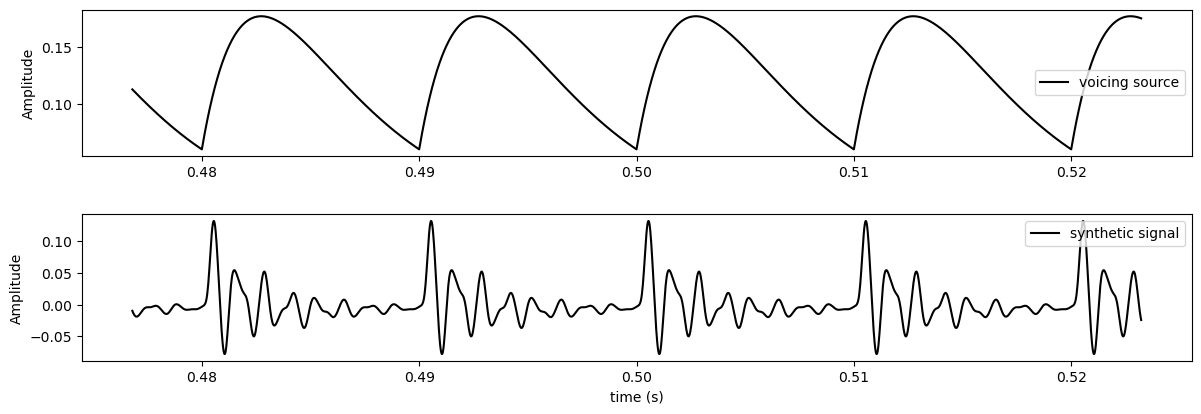

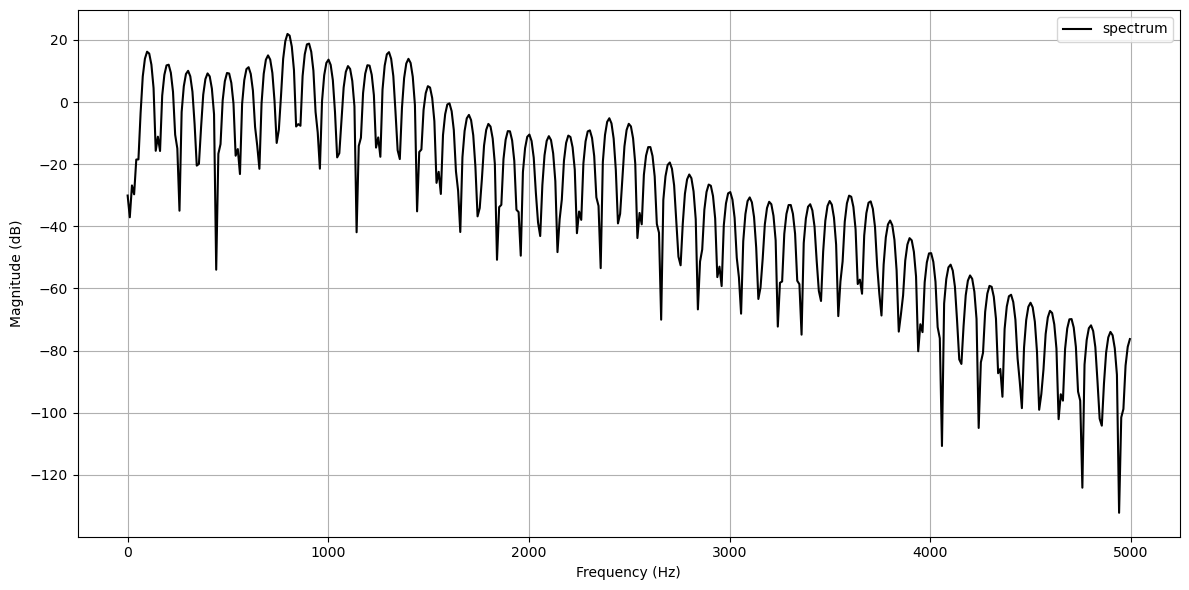

In [22]:
# vocal
vowel ='a'
# sampling rate
sr = 44100
# fundamental frequency
f0 = 100
# duration
dur = 1

# Sintetizar vocal
xv, vs, t = formant_synthesis(fs=sr, f0=f0, dur=dur, vowel=vowel)

print("Sintesis de vocal = {} con f0 = {} Hz".format(vowel, f0))

display(Audio(xv.flatten(), rate=sr))

# muestras de ventana
N = int(2**np.ceil(np.log2(round(4*sr/f0))))
# nfft (fft samples)
nfft = 2 * N
# maximum frequency
fmax = 5000
# frame indexes
tmid = round(dur/2*sr)
ind_ini = tmid - int(N/2)
ind_end = tmid + int(N/2)
# ventana suavizante
window = signal.windows.get_window('hann', N)

# signal frame
frame = xv[ind_ini:ind_end]

# windowed signal frame
frame_win = frame[:, 0] * window
# spectrum of the signal frame
Xv = np.fft.fft(frame_win, nfft)
# magnitude spectrum
magXv = np.abs(Xv)    

# frequency values
f = np.fft.fftfreq(nfft) * sr
ind_fmx = np.argwhere(f > fmax)[0][0]

plt.figure(figsize=(12,12))
plt.subplot(6, 1, 1)
plt.plot(t[ind_ini:ind_end], vs[ind_ini:ind_end], 'k', label='voicing source')
plt.ylabel('Amplitude')
plt.legend()
plt.subplot(6, 1, 2)
plt.plot(t[ind_ini:ind_end], xv[ind_ini:ind_end], 'k', label='synthetic signal')
plt.ylabel('Amplitude')
plt.xlabel('time (s)')
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12,6))
plt.plot(f[:ind_fmx], 20 * np.log10(magXv[:ind_fmx]), 'k', label='spectrum')
plt.legend()
plt.ylabel('Magnitude (dB)')
plt.xlabel('Frequency (Hz)')
plt.tight_layout()
plt.grid()

Luego de ejecutar el código: 

1. Evalúe auditivamente el resultado de la síntesis. ¿Logra diferenciar el sonido de cada vocal?
2. Compare la forma de onda de cada vocal. ¿Logra distinguir las diferencias dadas por las diferentes formantes?
3. Compare el espectro de cada vocal. ¿Logra distinguir con claridad las diferencias en la ubicación de las dos primeras formantes?
4. Considere el mapa de formantes presentado en clase. ¿La ubicación de las formantes sigue esa caracterización? 
5. Nuevamente evalúe auditivamente el resultado de la síntesis. ¿Qué limitantes identifica en la síntesis que hacen que el sonido sea poco realista?